In [20]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter

# Set style untuk visualisasi yang lebih baik
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [21]:
# Load metadata dari mkn_house_metadata.json
with open("../data/metadata/mkn_house_metadata.json", "r", encoding="utf-8") as f:
    data = json.load(f)

print(f"Total Rumah: {len(data)}")
print(f"Struktur data: {json.dumps(data[0], indent=2)[:500]}...")

Total Rumah: 1195
Struktur data: {
  "house_id": "H00001",
  "house_type": "multi",
  "split": "test",
  "source_group_id": "GID00001",
  "match": false,
  "kelayakan_rumah": "layak",
  "images": [
    {
      "image_id": "IMG000006",
      "image_path": "rlh_ext/mkn_single_rlh_ext_0006.jpg",
      "view_type": "exterior"
    },
    {
      "image_id": "IMG000577",
      "image_path": "rlh_int/mkn_single_rlh_int_0165.jpg",
      "view_type": "interior"
    }
  ],
  "prediksi": {
    "atap": "seng",
    "dinding": "tembok",
    ...


In [22]:
# Membuat dataframe untuk rumah (house-level)
houses_data = []

for rec in data:
    num_images = len(rec.get("images", []))
    num_exterior = sum(1 for img in rec.get("images", []) if img.get("view_type") == "exterior")
    num_interior = sum(1 for img in rec.get("images", []) if img.get("view_type") == "interior")
    
    houses_data.append({
        "house_id": rec["house_id"],
        "house_type": rec.get("house_type", "unknown"),
        "split": rec["split"],
        "kelayakan_rumah": rec["kelayakan_rumah"],
        "match": rec.get("match", False),
        "num_images": num_images,
        "num_exterior": num_exterior,
        "num_interior": num_interior,
    })

df_houses = pd.DataFrame(houses_data)
print("\n=== RINGKASAN HOUSE-LEVEL DATA ===")
print(f"Total Rumah: {len(df_houses)}")
print(f"\nTipe Rumah:")
print(df_houses["house_type"].value_counts())
print(f"\nDistribusi Split:")
print(df_houses["split"].value_counts())
print(f"\nKelayakan Rumah:")
print(df_houses["kelayakan_rumah"].value_counts())


=== RINGKASAN HOUSE-LEVEL DATA ===
Total Rumah: 1195

Tipe Rumah:
house_type
single    1095
multi      100
Name: count, dtype: int64

Distribusi Split:
split
train    785
test     243
val      167
Name: count, dtype: int64

Kelayakan Rumah:
kelayakan_rumah
layak          707
tidak_layak    488
Name: count, dtype: int64


In [23]:
# Membuat dataframe untuk images (image-level)
images_data = []

for rec in data:
    for img in rec.get("images", []):
        images_data.append({
            "house_id": rec["house_id"],
            "image_id": img["image_id"],
            "image_path": img["image_path"],
            "view_type": img["view_type"],
            "split": rec["split"],
            "kelayakan_rumah": rec["kelayakan_rumah"],
            "house_type": rec.get("house_type", "unknown"),
        })

df_images = pd.DataFrame(images_data)
print("\n=== RINGKASAN IMAGE-LEVEL DATA ===")
print(f"Total Gambar: {len(df_images)}")
print(f"\nDistribusi View Type:")
print(df_images["view_type"].value_counts())
print(f"\nGambar per Split:")
print(df_images["split"].value_counts())


=== RINGKASAN IMAGE-LEVEL DATA ===
Total Gambar: 1295

Distribusi View Type:
view_type
exterior    912
interior    383
Name: count, dtype: int64

Gambar per Split:
split
train    843
test     271
val      181
Name: count, dtype: int64


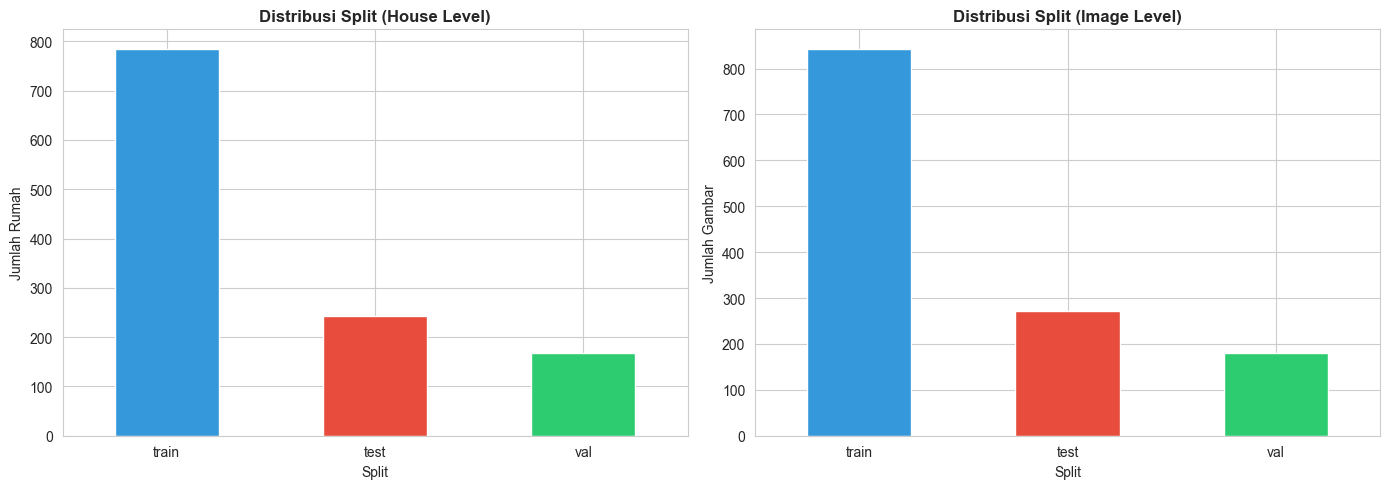

In [24]:
# Visualisasi 1: Distribusi Split pada House Level
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# House Level
df_houses["split"].value_counts().plot(kind="bar", ax=ax1, color=['#3498db', '#e74c3c', '#2ecc71'])
ax1.set_title("Distribusi Split (House Level)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Split")
ax1.set_ylabel("Jumlah Rumah")
ax1.tick_params(axis='x', rotation=0)

# Image Level
df_images["split"].value_counts().plot(kind="bar", ax=ax2, color=['#3498db', '#e74c3c', '#2ecc71'])
ax2.set_title("Distribusi Split (Image Level)", fontsize=12, fontweight='bold')
ax2.set_xlabel("Split")
ax2.set_ylabel("Jumlah Gambar")
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

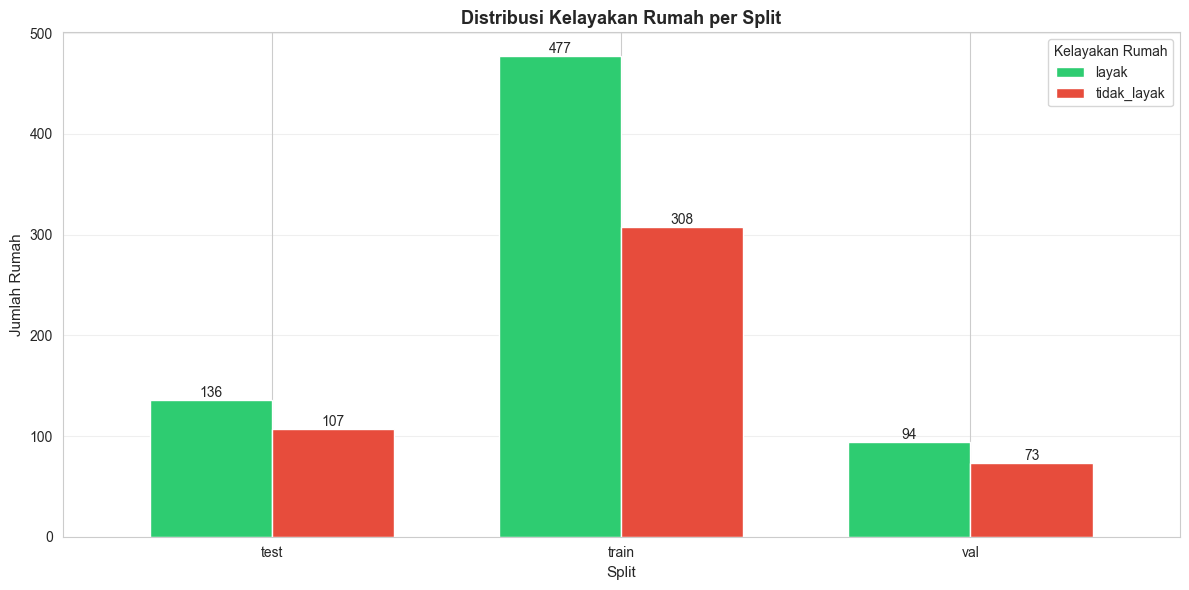

In [25]:
# Visualisasi 2: Kelayakan Rumah per Split
fig, ax = plt.subplots(figsize=(12, 6))

crosstab_kelayakan = pd.crosstab(df_houses["split"], df_houses["kelayakan_rumah"])
crosstab_kelayakan.plot(kind="bar", ax=ax, color=['#2ecc71', '#e74c3c'], width=0.7)
ax.set_title("Distribusi Kelayakan Rumah per Split", fontsize=13, fontweight='bold')
ax.set_xlabel("Split", fontsize=11)
ax.set_ylabel("Jumlah Rumah", fontsize=11)
ax.tick_params(axis='x', rotation=0)
ax.legend(title="Kelayakan Rumah")
ax.grid(axis='y', alpha=0.3)

# Tambahkan nilai di atas bar
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

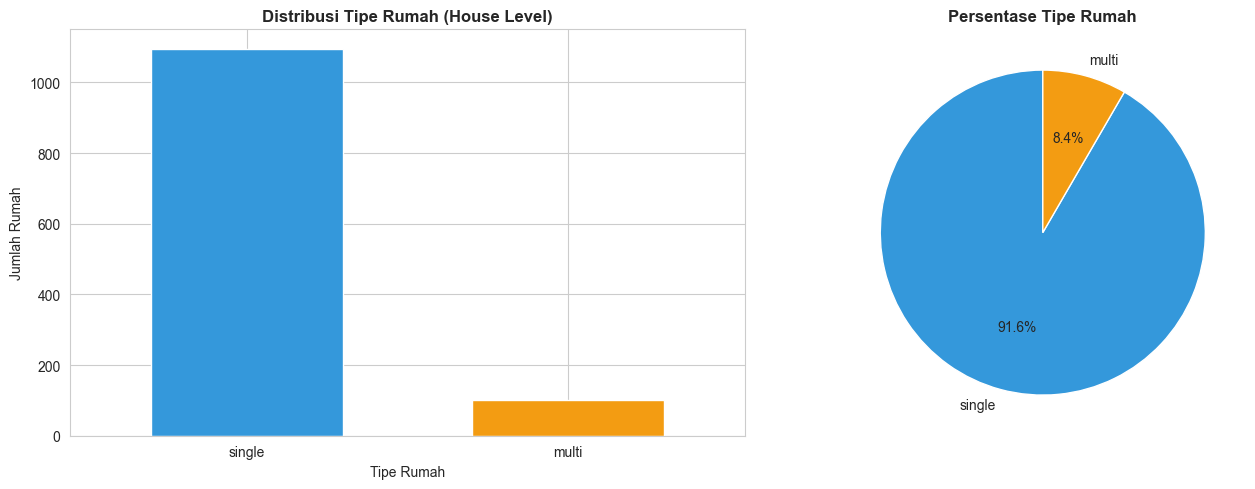

In [26]:
# Visualisasi 3: Tipe Rumah (Multi vs Single)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Count
house_type_count = df_houses["house_type"].value_counts()
house_type_count.plot(kind="bar", ax=ax1, color=['#3498db', '#f39c12'], width=0.6)
ax1.set_title("Distribusi Tipe Rumah (House Level)", fontsize=12, fontweight='bold')
ax1.set_xlabel("Tipe Rumah")
ax1.set_ylabel("Jumlah Rumah")
ax1.tick_params(axis='x', rotation=0)

# Pie chart
ax2.pie(house_type_count, labels=house_type_count.index, autopct='%1.1f%%', 
        colors=['#3498db', '#f39c12'], startangle=90)
ax2.set_title("Persentase Tipe Rumah", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

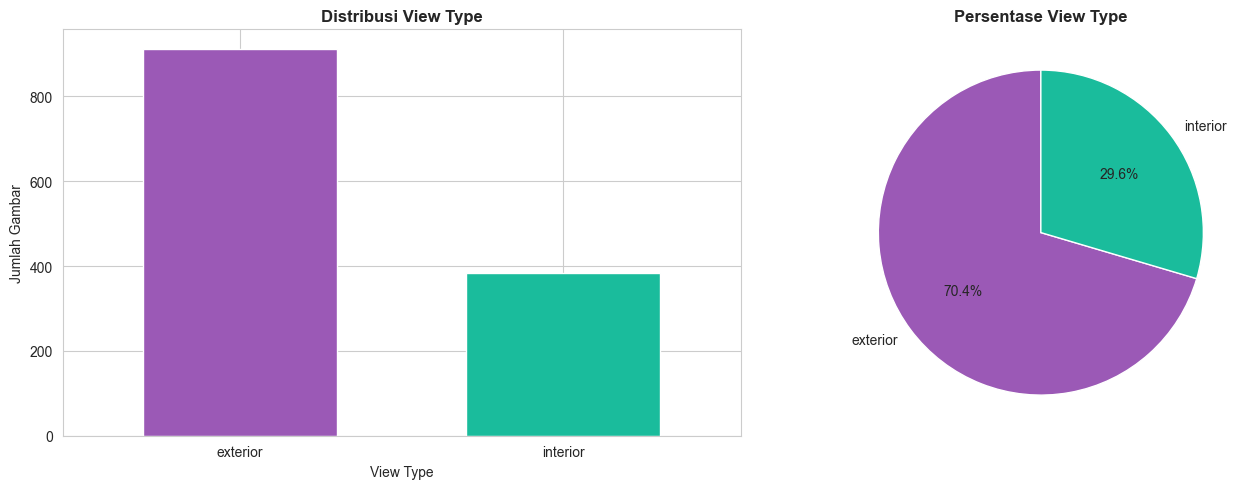

In [27]:
# Visualisasi 4: View Type Distribution (Exterior vs Interior)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Count
view_type_count = df_images["view_type"].value_counts()
view_type_count.plot(kind="bar", ax=ax1, color=['#9b59b6', '#1abc9c'], width=0.6)
ax1.set_title("Distribusi View Type", fontsize=12, fontweight='bold')
ax1.set_xlabel("View Type")
ax1.set_ylabel("Jumlah Gambar")
ax1.tick_params(axis='x', rotation=0)

# Pie chart
ax2.pie(view_type_count, labels=view_type_count.index, autopct='%1.1f%%', 
        colors=['#9b59b6', '#1abc9c'], startangle=90)
ax2.set_title("Persentase View Type", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

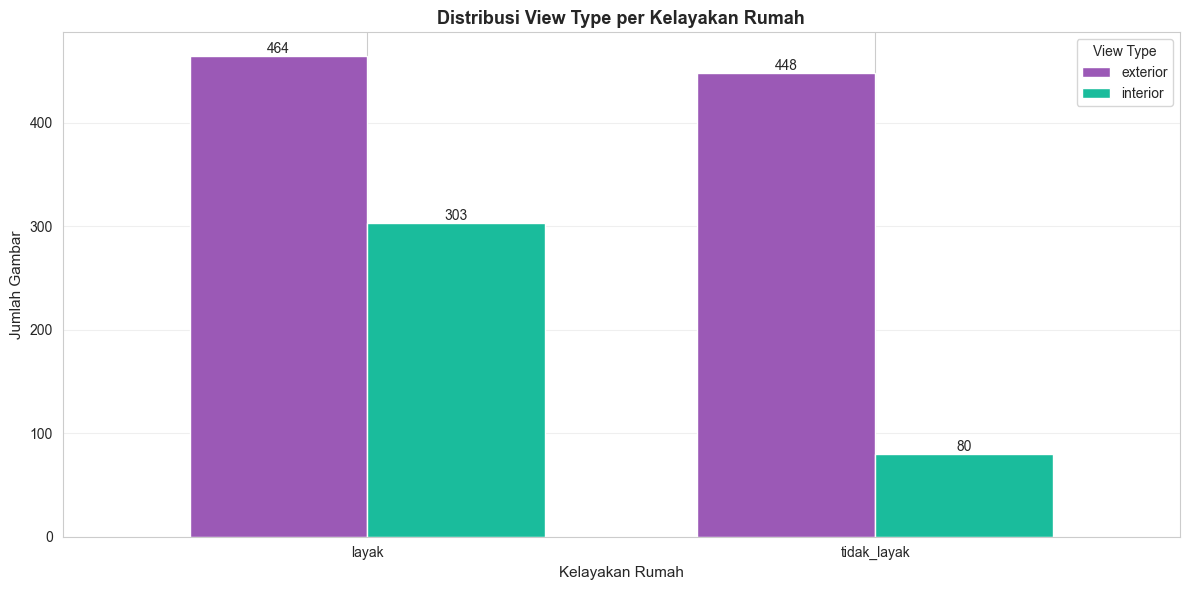

In [28]:
# Visualisasi 5: View Type per Kelayakan Rumah
fig, ax = plt.subplots(figsize=(12, 6))

crosstab_view_kelayakan = pd.crosstab(df_images["kelayakan_rumah"], df_images["view_type"])
crosstab_view_kelayakan.plot(kind="bar", ax=ax, color=['#9b59b6', '#1abc9c'], width=0.7)
ax.set_title("Distribusi View Type per Kelayakan Rumah", fontsize=13, fontweight='bold')
ax.set_xlabel("Kelayakan Rumah", fontsize=11)
ax.set_ylabel("Jumlah Gambar", fontsize=11)
ax.tick_params(axis='x', rotation=0)
ax.legend(title="View Type")
ax.grid(axis='y', alpha=0.3)

# Tambahkan nilai di atas bar
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()


=== STATISTIK JUMLAH GAMBAR PER RUMAH ===
           mean  min  max  count
split                           
test   1.115226    1    2    243
train  1.073885    1    2    785
val    1.083832    1    2    167


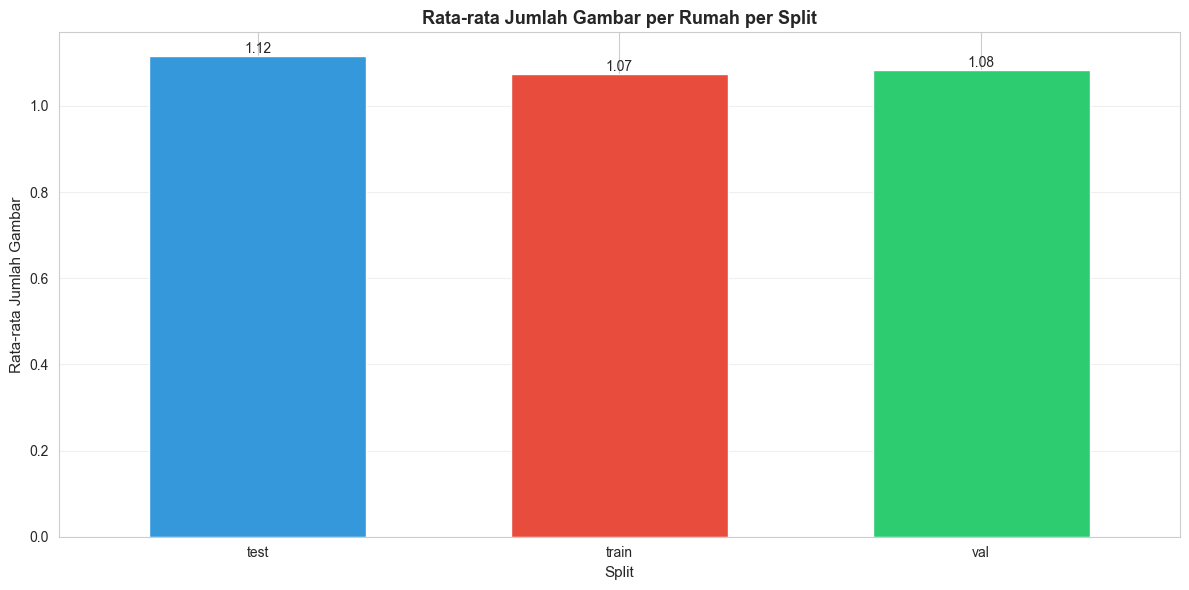

In [29]:
# Visualisasi 6: Rata-rata Jumlah Gambar per Rumah
fig, ax = plt.subplots(figsize=(12, 6))

avg_images = df_houses.groupby("split")["num_images"].agg(['mean', 'min', 'max', 'count'])
print("\n=== STATISTIK JUMLAH GAMBAR PER RUMAH ===")
print(avg_images)

# Bar plot
avg_images['mean'].plot(kind="bar", ax=ax, color=['#3498db', '#e74c3c', '#2ecc71'], width=0.6, capsize=5)
ax.set_title("Rata-rata Jumlah Gambar per Rumah per Split", fontsize=13, fontweight='bold')
ax.set_xlabel("Split", fontsize=11)
ax.set_ylabel("Rata-rata Jumlah Gambar", fontsize=11)
ax.tick_params(axis='x', rotation=0)
ax.grid(axis='y', alpha=0.3)

# Tambahkan nilai
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.tight_layout()
plt.show()

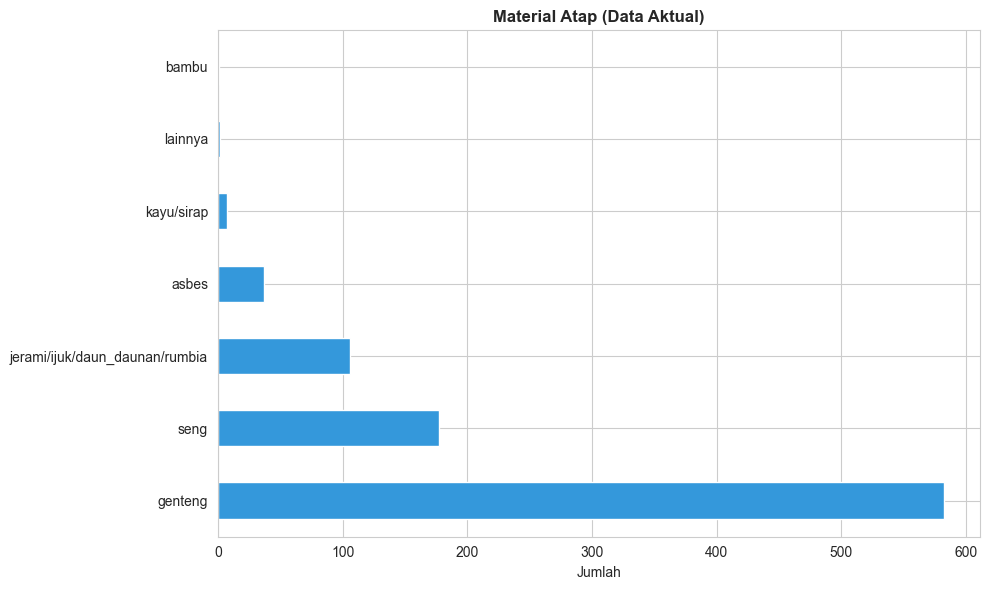

In [30]:
# Visualisasi 7: Analisis Material - Atap
fig, ax = plt.subplots(figsize=(10, 6))

# Collect atap data
atap_prediksi = []

for rec in data:
    if "prediksi" in rec and "atap" in rec["prediksi"]:
        atap_prediksi.append(rec["prediksi"]["atap"])

# Plot data aktual
atap_pred_counts = pd.Series(atap_prediksi).value_counts()
atap_pred_counts.plot(kind="barh", ax=ax, color='#3498db')
ax.set_title("Material Atap (Data Aktual)", fontsize=12, fontweight='bold')
ax.set_xlabel("Jumlah")

plt.tight_layout()
plt.show()

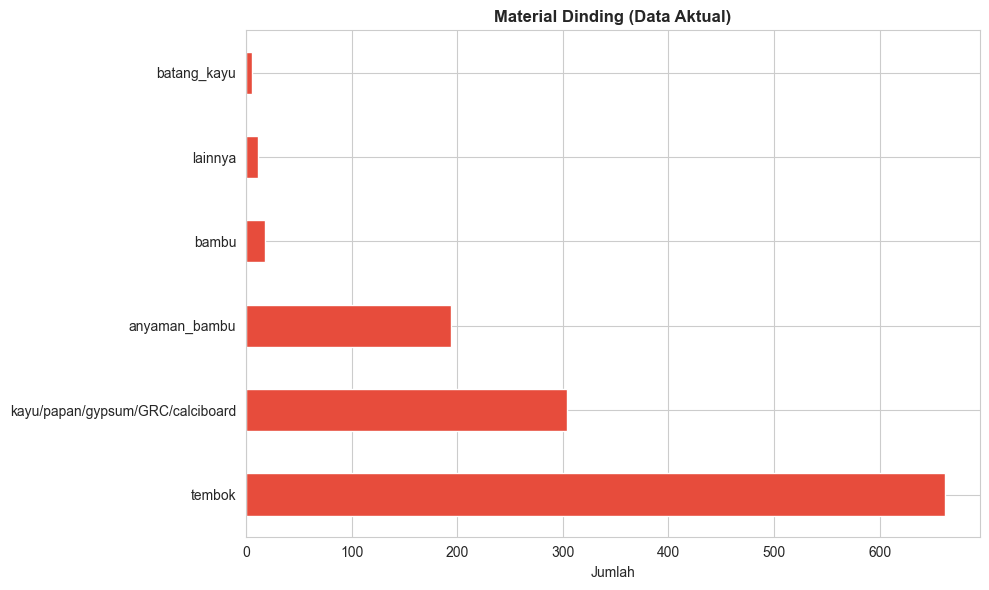

In [31]:
# Visualisasi 8: Analisis Material - Dinding
fig, ax = plt.subplots(figsize=(10, 6))

# Collect dinding data
dinding_prediksi = []

for rec in data:
    if "prediksi" in rec and "dinding" in rec["prediksi"]:
        dinding_prediksi.append(rec["prediksi"]["dinding"])

# Plot data aktual
dinding_pred_counts = pd.Series(dinding_prediksi).value_counts()
dinding_pred_counts.plot(kind="barh", ax=ax, color='#e74c3c')
ax.set_title("Material Dinding (Data Aktual)", fontsize=12, fontweight='bold')
ax.set_xlabel("Jumlah")

plt.tight_layout()
plt.show()

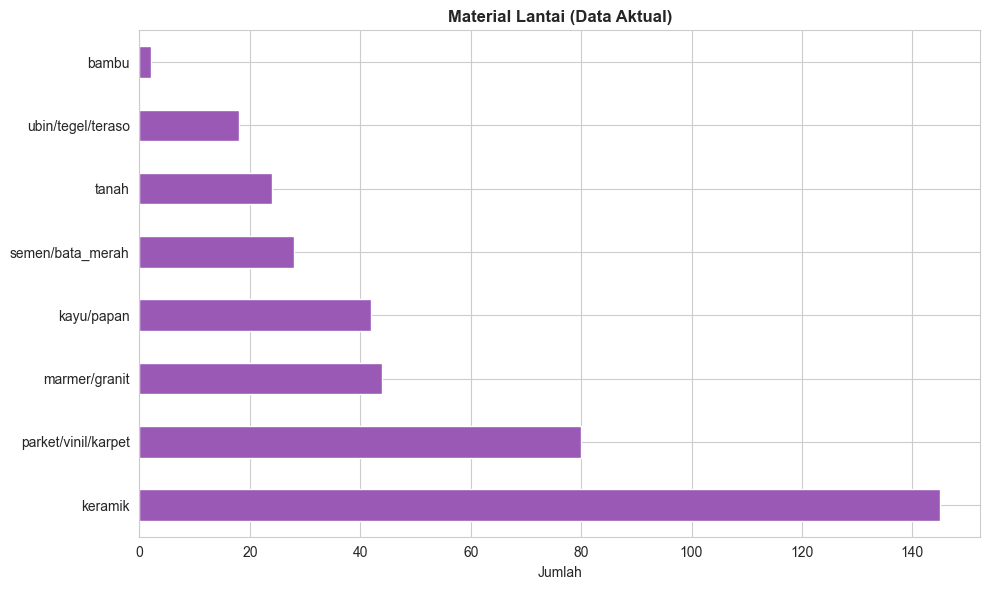

In [32]:
# Visualisasi 9: Analisis Material - Lantai
fig, ax = plt.subplots(figsize=(10, 6))

# Collect lantai data
lantai_prediksi = []

for rec in data:
    if "prediksi" in rec and "lantai" in rec["prediksi"]:
        lantai_prediksi.append(rec["prediksi"]["lantai"])

# Plot data aktual
lantai_pred_counts = pd.Series(lantai_prediksi).value_counts()
lantai_pred_counts.plot(kind="barh", ax=ax, color='#9b59b6')
ax.set_title("Material Lantai (Data Aktual)", fontsize=12, fontweight='bold')
ax.set_xlabel("Jumlah")

plt.tight_layout()
plt.show()

In [33]:
# Analisis: Akurasi Prediksi Material
print("\n=== ANALISIS AKURASI PREDIKSI MATERIAL ===")

correct_atap = sum(1 for rec in data if rec.get("prediksi", {}).get("atap") == rec.get("dtsen", {}).get("atap"))
correct_dinding = sum(1 for rec in data if rec.get("prediksi", {}).get("dinding") == rec.get("dtsen", {}).get("dinding"))
correct_lantai = sum(1 for rec in data if rec.get("prediksi", {}).get("lantai") == rec.get("dtsen", {}).get("lantai"))

total_houses = len(data)

print(f"Akurasi Atap: {correct_atap}/{total_houses} ({correct_atap/total_houses*100:.2f}%)")
print(f"Akurasi Dinding: {correct_dinding}/{total_houses} ({correct_dinding/total_houses*100:.2f}%)")
print(f"Akurasi Lantai: {correct_lantai}/{total_houses} ({correct_lantai/total_houses*100:.2f}%)")


=== ANALISIS AKURASI PREDIKSI MATERIAL ===
Akurasi Atap: 748/1195 (62.59%)
Akurasi Dinding: 597/1195 (49.96%)
Akurasi Lantai: 995/1195 (83.26%)


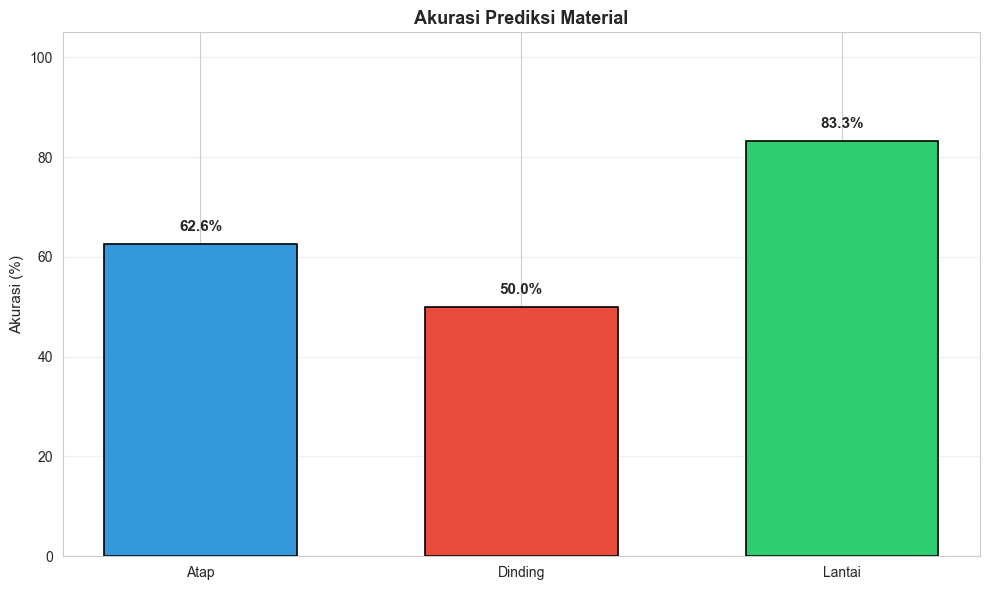

In [34]:
# Visualisasi 10: Akurasi Prediksi Material
fig, ax = plt.subplots(figsize=(10, 6))

materials = ['Atap', 'Dinding', 'Lantai']
accuracies = [
    correct_atap/total_houses*100,
    correct_dinding/total_houses*100,
    correct_lantai/total_houses*100
]

colors = ['#3498db', '#e74c3c', '#2ecc71']
bars = ax.bar(materials, accuracies, color=colors, width=0.6, edgecolor='black', linewidth=1.2)

ax.set_title("Akurasi Prediksi Material", fontsize=13, fontweight='bold')
ax.set_ylabel("Akurasi (%)", fontsize=11)
ax.set_ylim([0, 105])
ax.grid(axis='y', alpha=0.3)

# Tambahkan nilai
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 2, f'{acc:.1f}%', 
            ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()


=== ANALISIS MATCH STATUS ===
Match True: 597
Match False: 598


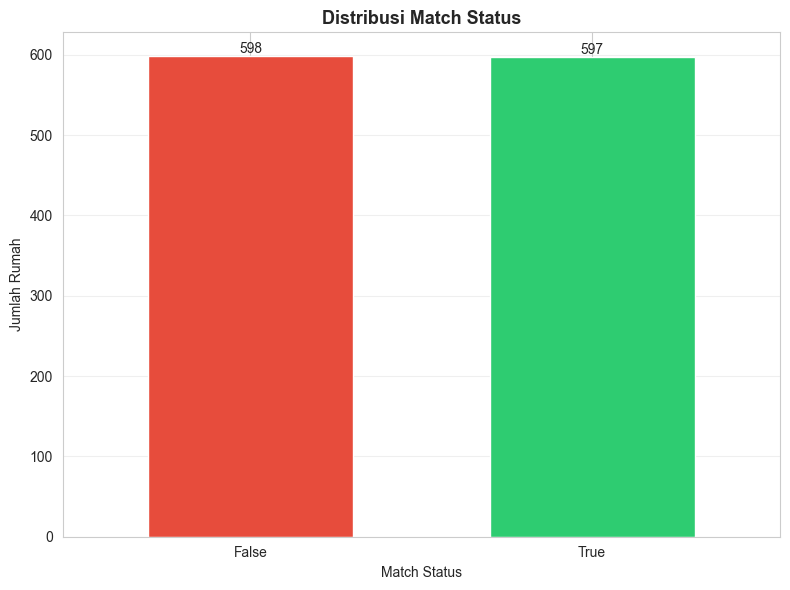

In [35]:
# Analisis: Match Status
print("\n=== ANALISIS MATCH STATUS ===")
match_status = df_houses["match"].value_counts()
print(f"Match True: {match_status.get(True, 0)}")
print(f"Match False: {match_status.get(False, 0)}")

# Visualisasi
fig, ax = plt.subplots(figsize=(8, 6))
match_status.plot(kind="bar", ax=ax, color=['#e74c3c', '#2ecc71'], width=0.6)
ax.set_title("Distribusi Match Status", fontsize=13, fontweight='bold')
ax.set_xlabel("Match Status")
ax.set_ylabel("Jumlah Rumah")
ax.tick_params(axis='x', rotation=0)
ax.set_xticklabels(['False', 'True'])
ax.grid(axis='y', alpha=0.3)

# Tambahkan nilai
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

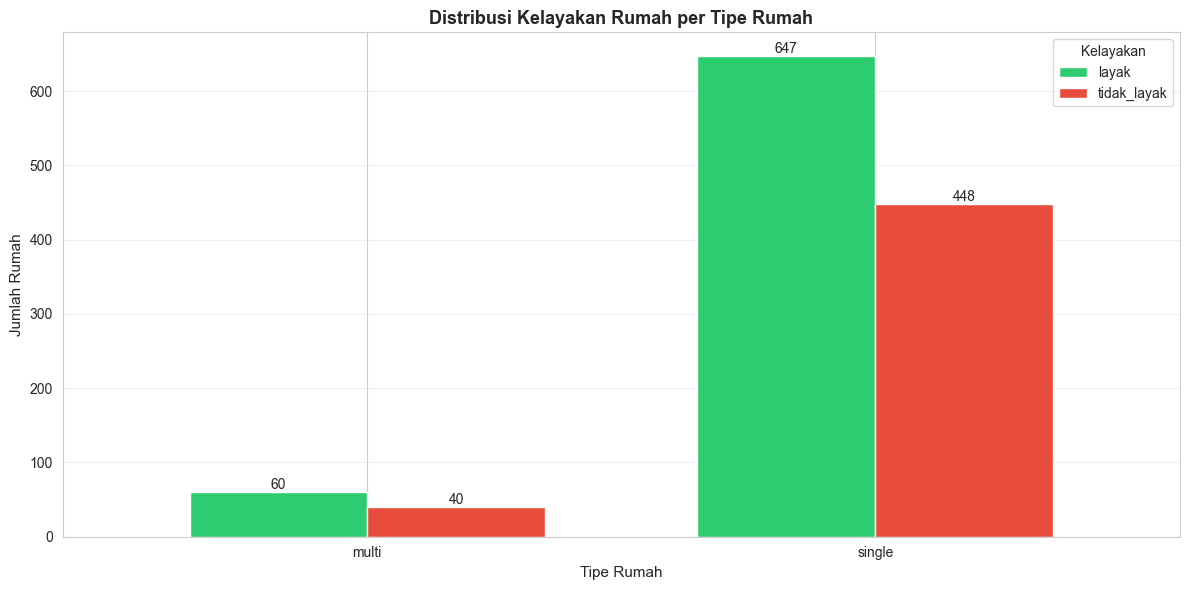

In [36]:
# Visualisasi 11: Kelayakan per House Type
fig, ax = plt.subplots(figsize=(12, 6))

crosstab_type_kelayakan = pd.crosstab(df_houses["house_type"], df_houses["kelayakan_rumah"])
crosstab_type_kelayakan.plot(kind="bar", ax=ax, color=['#2ecc71', '#e74c3c'], width=0.7)
ax.set_title("Distribusi Kelayakan Rumah per Tipe Rumah", fontsize=13, fontweight='bold')
ax.set_xlabel("Tipe Rumah", fontsize=11)
ax.set_ylabel("Jumlah Rumah", fontsize=11)
ax.tick_params(axis='x', rotation=0)
ax.legend(title="Kelayakan")
ax.grid(axis='y', alpha=0.3)

# Tambahkan nilai
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [37]:
# Summary Statistics
print("\n=== RINGKASAN STATISTIK LENGKAP ===")
print(f"\nJumlah Rumah: {len(df_houses)}")
print(f"Jumlah Gambar: {len(df_images)}")
print(f"Rata-rata Gambar per Rumah: {len(df_images) / len(df_houses):.2f}")

print("\n--- Distribusi Split ---")
print(df_houses["split"].value_counts().sort_index())

print("\n--- Distribusi Kelayakan ---")
print(df_houses["kelayakan_rumah"].value_counts())
kelayakan_pct = (df_houses["kelayakan_rumah"].value_counts() / len(df_houses) * 100).round(2)
print("\nPersentase:")
print(kelayakan_pct)

print("\n--- Distribusi Tipe Rumah ---")
print(df_houses["house_type"].value_counts())

print("\n--- Distribusi View Type ---")
print(df_images["view_type"].value_counts())
view_pct = (df_images["view_type"].value_counts() / len(df_images) * 100).round(2)
print("\nPersentase:")
print(view_pct)


=== RINGKASAN STATISTIK LENGKAP ===

Jumlah Rumah: 1195
Jumlah Gambar: 1295
Rata-rata Gambar per Rumah: 1.08

--- Distribusi Split ---
split
test     243
train    785
val      167
Name: count, dtype: int64

--- Distribusi Kelayakan ---
kelayakan_rumah
layak          707
tidak_layak    488
Name: count, dtype: int64

Persentase:
kelayakan_rumah
layak          59.16
tidak_layak    40.84
Name: count, dtype: float64

--- Distribusi Tipe Rumah ---
house_type
single    1095
multi      100
Name: count, dtype: int64

--- Distribusi View Type ---
view_type
exterior    912
interior    383
Name: count, dtype: int64

Persentase:
view_type
exterior    70.42
interior    29.58
Name: count, dtype: float64


In [38]:
# Statistik Detail per Split
print("\n=== STATISTIK DETAIL PER SPLIT ===")

for split in ['train', 'val', 'test']:
    split_houses = df_houses[df_houses["split"] == split]
    split_images = df_images[df_images["split"] == split]
    
    print(f"\n--- {split.upper()} ---")
    print(f"Jumlah Rumah: {len(split_houses)}")
    print(f"Jumlah Gambar: {len(split_images)}")
    print(f"Rata-rata Gambar/Rumah: {len(split_images) / len(split_houses):.2f}")
    print(f"Layak: {len(split_houses[split_houses['kelayakan_rumah'] == 'layak'])} ({len(split_houses[split_houses['kelayakan_rumah'] == 'layak'])/len(split_houses)*100:.1f}%)")
    print(f"Tidak Layak: {len(split_houses[split_houses['kelayakan_rumah'] == 'tidak_layak'])} ({len(split_houses[split_houses['kelayakan_rumah'] == 'tidak_layak'])/len(split_houses)*100:.1f}%)")


=== STATISTIK DETAIL PER SPLIT ===

--- TRAIN ---
Jumlah Rumah: 785
Jumlah Gambar: 843
Rata-rata Gambar/Rumah: 1.07
Layak: 477 (60.8%)
Tidak Layak: 308 (39.2%)

--- VAL ---
Jumlah Rumah: 167
Jumlah Gambar: 181
Rata-rata Gambar/Rumah: 1.08
Layak: 94 (56.3%)
Tidak Layak: 73 (43.7%)

--- TEST ---
Jumlah Rumah: 243
Jumlah Gambar: 271
Rata-rata Gambar/Rumah: 1.12
Layak: 136 (56.0%)
Tidak Layak: 107 (44.0%)
